# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: sharmaine heng



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [69]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report


# 1. Business Understanding
Goal: The goal of this project is to build a machine learning model that predicts whether a bank customer will subscribe to a term deposit after a direct marketing campaign. This is useful for a bank because marketing campaigns can be costly and time-consuming. By predicting which customers are more likely to subscribe, the bank can focus its marketing efforts on the right customers, improve campaign efficiency, and reduce wasted resources. This is a classification problem because the target variable is categorical. The model will predict either “yes”, meaning the customer subscribed to a term deposit, or “no”, meaning the customer did not subscribe.


# 2. Data Understanding

## 2.1 Load dataset

In [ ]:
df = pd.read_csv("bank-full.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [73]:
print("HI")
print("bte")

HI
bte


## 2.2 Summary Statistics

In [48]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()

Dataset shape: (45211, 17)

Column names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null

In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())  

Missing values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Summary statistics:


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


y
no     39922
yes     5289
Name: count, dtype: int64

Target variable percentage:
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


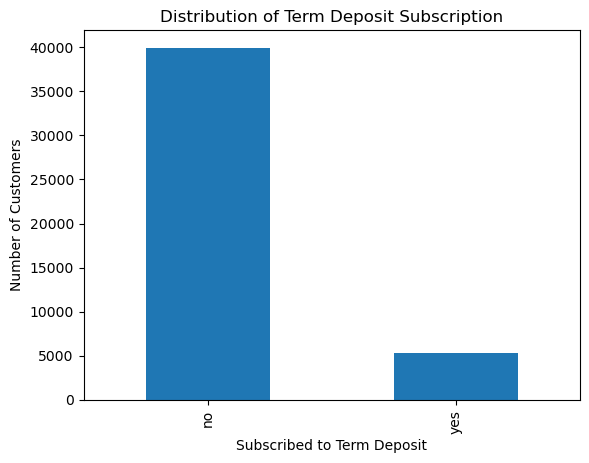

In [49]:
print(df["y"].value_counts())

print("\nTarget variable percentage:")
print(df["y"].value_counts(normalize=True) * 100)

df["y"].value_counts().plot(kind="bar")
plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Customers")
plt.show()

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

The dataset contains 45,211 customer records and 17 columns. It includes both numerical features, such as age, balance, day, duration, campaign, pdays and previous, as well as categorical features, such as job, marital, education, housing, loan, contact, month and poutcome. There are no missing values shown as null values in the dataset. However, some categorical columns contain the value “unknown”, which represents unclear or unavailable information. This means the dataset still requires some preparation before model training. The target variable is y, which shows whether the customer subscribed to a term deposit. The target distribution is imbalanced, with many more “no” values than “yes” values. Because of this imbalance, accuracy alone may not be enough to evaluate the model. Precision, recall and F1-score should also be considered to better understand how well the model predicts customers who actually subscribe.


### 2.3.1.1 Understanding distribution of target

In [50]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

print("\nNumber of categorical columns:", len(categorical_cols))
print("Number of numerical columns:", len(numerical_cols))

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Numerical columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Number of categorical columns: 10
Number of numerical columns: 7


### 2.3.1.2 Understanding distribution of features

In [51]:
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

Column: marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

Column: education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

Column: default
default
no     44396
yes      815
Name: count, dtype: int64

Column: housing
housing
yes    25130
no     20081
Name: count, dtype: int64

Column: loan
loan
no     37967
yes     7244
Name: count, dtype: int64

Column: contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

Column: month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403

### 2.3.2 Understanding relationship between variables

,age,balance,day,duration,campaign,pdays,previous,y_binary
age,1.000000,0.097783,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.025155
balance,0.097783,1.000000,0.004503,0.021560,-0.014578,0.003435,0.016674,0.052838
day,-0.009120,0.004503,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.028348
duration,-0.004648,0.021560,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.394521
campaign,0.004760,-0.014578,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.073172
pdays,-0.023758,0.003435,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.103621
previous,0.001288,0.016674,-0.051710,0.001203,-0.032855,0.454820,1.000000,0.093236
y_binary,0.025155,0.052838,-0.028348,0.394521,-0.073172,0.103621,0.093236,1.000000


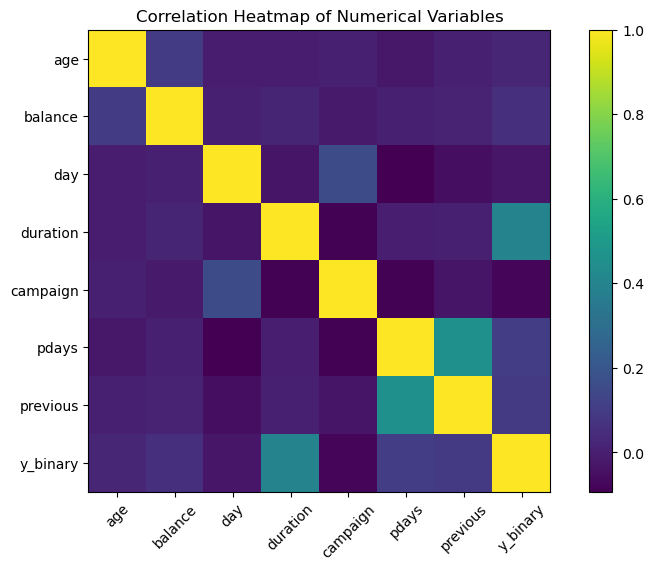

In [52]:
df["y_binary"] = df["y"].map({"yes": 1, "no": 0})

correlation_cols = numerical_cols + ["y_binary"]

corr_matrix = df[correlation_cols].corr()

display(corr_matrix)

plt.figure(figsize=(10, 6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(correlation_cols)), correlation_cols, rotation=45)
plt.yticks(range(len(correlation_cols)), correlation_cols)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y_binary, dtype: float64

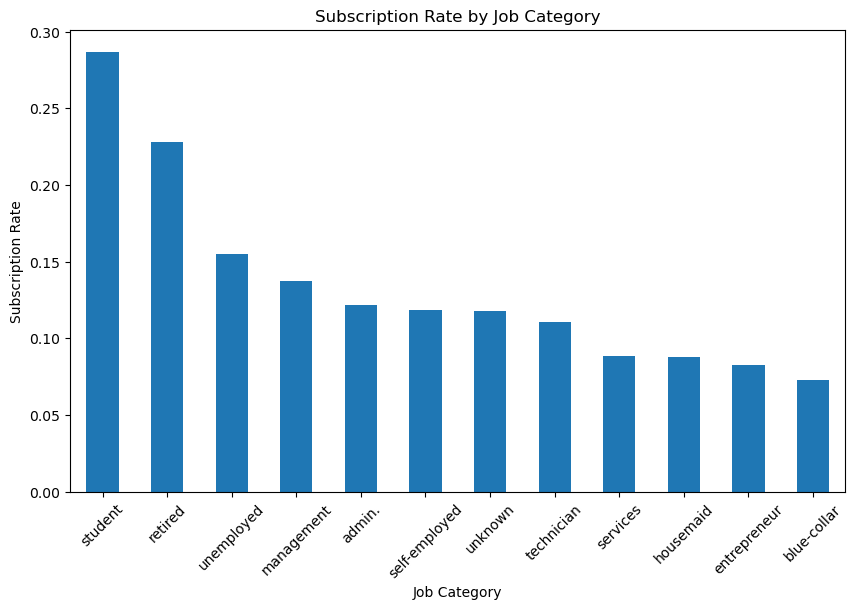

In [ ]:
job_subscription_rate = df.groupby("job")["y_binary"].mean().sort_values(ascending=False)

display(job_subscription_rate)

plt.figure(figsize=(10, 6))
job_subscription_rate.plot(kind="bar")
plt.title("Subscription Rate by Job Category")
plt.xlabel("Job Category")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.show()

month
jan    0.101212
feb    0.166478
mar    0.519916
apr    0.196794
may    0.067195
jun    0.102228
jul    0.090935
aug    0.110133
sep    0.464594
oct    0.437669
nov    0.101511
dec    0.467290
Name: y_binary, dtype: float64

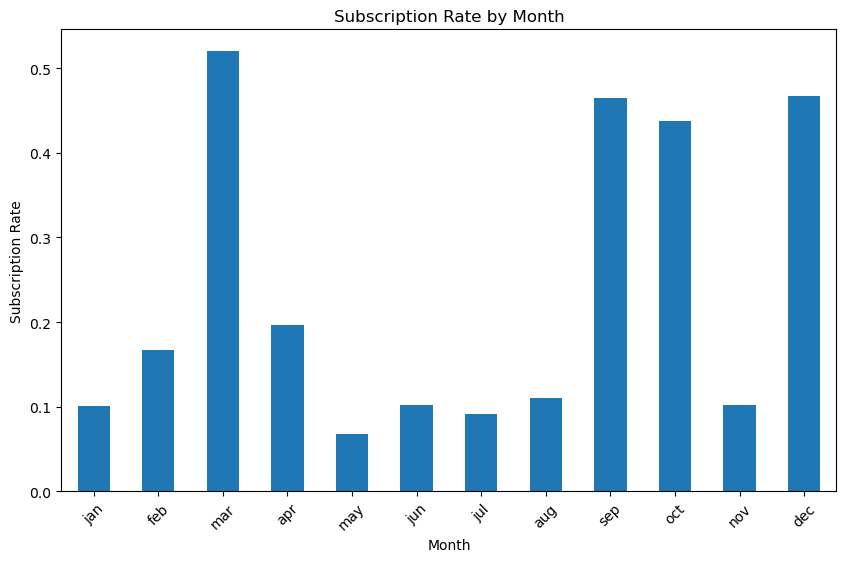

In [66]:
df["y_binary"] = df["y"].map({"yes": 1, "no": 0})

month_subscription_rate = df.groupby("month")["y_binary"].mean()

month_order = ["jan", "feb", "mar", "apr", "may", "jun", 
               "jul", "aug", "sep", "oct", "nov", "dec"]

month_subscription_rate = month_subscription_rate.reindex(month_order)

display(month_subscription_rate)

plt.figure(figsize=(10, 6))
month_subscription_rate.plot(kind="bar")
plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.show()

C:\Users\sharm\AppData\Local\Temp\ipykernel_23956\3482235799.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([campaign_no, campaign_yes], labels=["No", "Yes"])


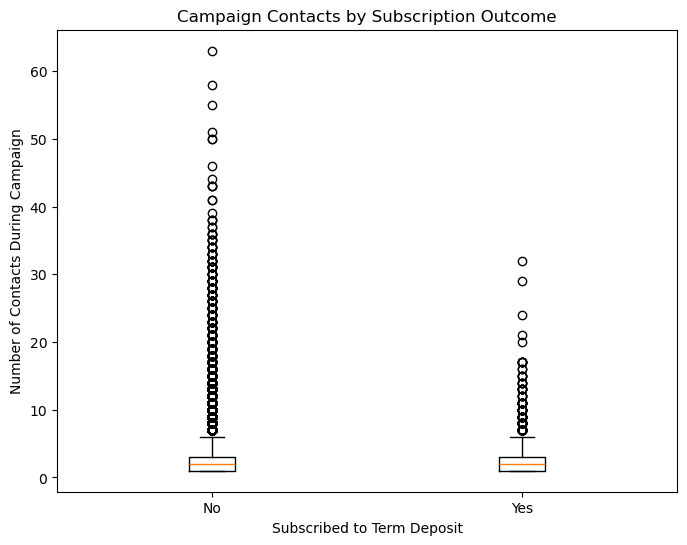

,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
no,39922.0,2.846350,3.212767,1.0,1.0,2.0,3.0,63.0
yes,5289.0,2.141047,1.921826,1.0,1.0,2.0,3.0,32.0


In [67]:
campaign_no = df[df["y"] == "no"]["campaign"]
campaign_yes = df[df["y"] == "yes"]["campaign"]

plt.figure(figsize=(8, 6))
plt.boxplot([campaign_no, campaign_yes], labels=["No", "Yes"])
plt.title("Campaign Contacts by Subscription Outcome")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Contacts During Campaign")
plt.show()

display(df.groupby("y")["campaign"].describe())

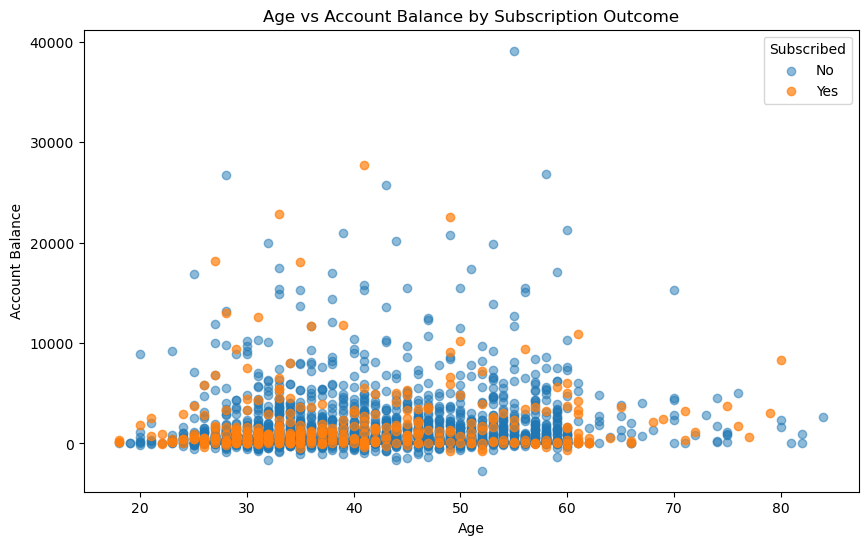

,age,balance
y,,
no,40.838986,1303.714969
yes,41.670070,1804.267915


In [68]:
df_sample = df.sample(n=3000, random_state=42)

not_subscribed = df_sample[df_sample["y"] == "no"]
subscribed = df_sample[df_sample["y"] == "yes"]

plt.figure(figsize=(10, 6))

plt.scatter(
    not_subscribed["age"],
    not_subscribed["balance"],
    alpha=0.5,
    label="No"
)

plt.scatter(
    subscribed["age"],
    subscribed["balance"],
    alpha=0.7,
    label="Yes"
)

plt.title("Age vs Account Balance by Subscription Outcome")
plt.xlabel("Age")
plt.ylabel("Account Balance")
plt.legend(title="Subscribed")
plt.show()

display(df.groupby("y")[["age", "balance"]].mean())

The correlation analysis shows the relationship between the numerical variables and the target variable, y_binary. The variable duration appears to have the strongest relationship with whether a customer subscribes to a term deposit. This suggests that customers who spend a longer time speaking to the bank during the campaign are more likely to subscribe. However, duration should be treated carefully because it is only known after the customer has been contacted. If the bank wants to predict whether a customer will subscribe before making the call, duration may not be available yet. Therefore, duration is useful for analysis, but it may also be a limitation when building a realistic prediction model. Other numerical variables such as age, balance, campaign, pdays and previous have weaker relationships with the target variable. This shows that the model should use a combination of both numerical and categorical features instead of relying on only one variable.


# 3. Data Preparation

## 3.1 Data Cleaning

In [53]:
df_model = df.copy()

df_model = df_model.drop(columns=["y_binary"], errors="ignore")

duplicates_before = df_model.duplicated().sum()
df_model = df_model.drop_duplicates()
duplicates_after = df_model.duplicated().sum()

print("Number of duplicated rows before cleaning:", duplicates_before)
print("Number of duplicated rows after cleaning:", duplicates_after)

df_model["target"] = df_model["y"].map({"yes": 1, "no": 0})

df_model.head()

Number of duplicated rows before cleaning: 0
Number of duplicated rows after cleaning: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,0


In [44]:
df_model["was_contacted_before"] = df_model["pdays"].apply(lambda x: 0 if x == -1 else 1)

df_model["has_any_loan"] = df_model.apply(
    lambda row: 1 if row["housing"] == "yes" or row["loan"] == "yes" else 0,
    axis=1
)

df_model["campaign_intensity"] = pd.cut(
    df_model["campaign"],
    bins=[0, 1, 3, 10, 100],
    labels=["single_contact", "low_contact", "medium_contact", "high_contact"]
)

df_model[[
    "pdays", "was_contacted_before",
    "housing", "loan", "has_any_loan",
    "campaign", "campaign_intensity"
]].head()

,pdays,was_contacted_before,housing,loan,has_any_loan,campaign,campaign_intensity
0,-1,0,yes,no,1,1,single_contact
1,-1,0,yes,no,1,1,single_contact
2,-1,0,yes,yes,1,1,single_contact
3,-1,0,yes,no,1,1,single_contact
4,-1,0,no,no,0,1,single_contact


## 3.2 Train-Test Split

In [56]:
X = df_model.drop(columns=["y", "target", "duration"])

y = df_model["target"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Number of features:", X.shape[1])

print("\nCategorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print("\nTarget distribution:")
print(y.value_counts())

Number of features: 15

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical features:
['age', 'balance', 'day', 'campaign', 'pdays', 'previous']

Target distribution:
target
0    39922
1     5289
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training feature shape: (36168, 15)
Testing feature shape: (9043, 15)

Training target distribution:
target
0    88.301814
1    11.698186
Name: proportion, dtype: float64

Testing target distribution:
target
0    88.300343
1    11.699657
Name: proportion, dtype: float64


In [57]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")
print("Numerical features will be scaled.")
print("Categorical features will be one-hot encoded.")

Preprocessing pipeline created successfully.
Numerical features will be scaled.
Categorical features will be one-hot encoded.


# 4. Modelling

### 4.2 Train Model

In [58]:
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]
)

log_reg_model.fit(X_train, y_train)

y_pred_log_reg = log_reg_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Precision:", precision_score(y_test, y_pred_log_reg))
print("Recall:", recall_score(y_test, y_pred_log_reg))
print("F1 Score:", f1_score(y_test, y_pred_log_reg))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_reg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Results
Accuracy: 0.7548379962401858
Precision: 0.2662363856393707
Recall: 0.6238185255198487
F1 Score: 0.37319762510602206

Confusion Matrix:
[[6166 1819]
 [ 398  660]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      7985
           1       0.27      0.62      0.37      1058

    accuracy                           0.75      9043
   macro avg       0.60      0.70      0.61      9043
weighted avg       0.86      0.75      0.79      9043



In [ ]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced",
            max_depth=5
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_decision_tree = decision_tree_model.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_decision_tree))
print("Precision:", precision_score(y_test, y_pred_decision_tree))
print("Recall:", recall_score(y_test, y_pred_decision_tree))
print("F1 Score:", f1_score(y_test, y_pred_decision_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_decision_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_decision_tree))

Decision Tree Results
Accuracy: 0.7960853698993697
Precision: 0.30070993914807304
Recall: 0.5604914933837429
F1 Score: 0.3914191419141914

Confusion Matrix:
[[6606 1379]
 [ 465  593]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      7985
           1       0.30      0.56      0.39      1058

    accuracy                           0.80      9043
   macro avg       0.62      0.69      0.63      9043
weighted avg       0.86      0.80      0.82      9043



In [59]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=10,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_random_forest = random_forest_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_random_forest))
print("Precision:", precision_score(y_test, y_pred_random_forest))
print("Recall:", recall_score(y_test, y_pred_random_forest))
print("F1 Score:", f1_score(y_test, y_pred_random_forest))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_random_forest))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_random_forest))

Random Forest Results
Accuracy: 0.8170960964281765
Precision: 0.34132055378061765
Recall: 0.6058601134215501
F1 Score: 0.4366485013623978

Confusion Matrix:
[[6748 1237]
 [ 417  641]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89      7985
           1       0.34      0.61      0.44      1058

    accuracy                           0.82      9043
   macro avg       0.64      0.73      0.66      9043
weighted avg       0.87      0.82      0.84      9043



In [ ]:
gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gradient_boosting))
print("Precision:", precision_score(y_test, y_pred_gradient_boosting))
print("Recall:", recall_score(y_test, y_pred_gradient_boosting))
print("F1 Score:", f1_score(y_test, y_pred_gradient_boosting))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gradient_boosting))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gradient_boosting))

Gradient Boosting Results
Accuracy: 0.8942828707287405
Precision: 0.659375
Recall: 0.1994328922495274
F1 Score: 0.3062409288824383

Confusion Matrix:
[[7876  109]
 [ 847  211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.66      0.20      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



# 5. Model Evaluation

In [60]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        accuracy_score(y_test, y_pred_decision_tree),
        accuracy_score(y_test, y_pred_random_forest),
        accuracy_score(y_test, y_pred_gradient_boosting)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log_reg),
        precision_score(y_test, y_pred_decision_tree),
        precision_score(y_test, y_pred_random_forest),
        precision_score(y_test, y_pred_gradient_boosting)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log_reg),
        recall_score(y_test, y_pred_decision_tree),
        recall_score(y_test, y_pred_random_forest),
        recall_score(y_test, y_pred_gradient_boosting)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log_reg),
        f1_score(y_test, y_pred_decision_tree),
        f1_score(y_test, y_pred_random_forest),
        f1_score(y_test, y_pred_gradient_boosting)
    ]
})

# Sort by F1 Score because the dataset is imbalanced
model_results = model_results.sort_values(by="F1 Score", ascending=False)

display(model_results)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.817096,0.341321,0.605860,0.436649
1,Decision Tree,0.796085,0.300710,0.560491,0.391419
0,Logistic Regression,0.754838,0.266236,0.623819,0.373198
3,Gradient Boosting,0.894283,0.659375,0.199433,0.306241


The model comparison shows that Random Forest achieved the best overall performance based on F1-score. Although Gradient Boosting had the highest accuracy, its recall was much lower, meaning it was weaker at identifying customers who actually subscribed to a term deposit. Since the dataset is imbalanced, with many more “no” values than “yes” values, accuracy alone is not the best metric to choose the final model. F1-score is more suitable because it balances precision and recall. Based on this, Random Forest is selected as the final model because it provides the strongest balance between correctly identifying subscribing customers and reducing incorrect predictions.


In [61]:
new_customer = pd.DataFrame({
    "age": [35],
    "job": ["management"],
    "marital": ["married"],
    "education": ["tertiary"],
    "default": ["no"],
    "balance": [1500],
    "housing": ["yes"],
    "loan": ["no"],
    "contact": ["cellular"],
    "day": [15],
    "month": ["may"],
    "campaign": [2],
    "pdays": [-1],
    "previous": [0],
    "poutcome": ["unknown"]
})

new_prediction = random_forest_model.predict(new_customer)

if new_prediction[0] == 1:
    print("Prediction: The customer is likely to subscribe to a term deposit.")
else:
    print("Prediction: The customer is unlikely to subscribe to a term deposit.")

Prediction: The customer is unlikely to subscribe to a term deposit.


A new customer profile was created to test how the final Random Forest model predicts unseen data. The customer information included demographic details, financial details and campaign-related details such as age, job, education, balance, housing loan status, contact type and previous campaign outcome. The model used these input features to predict whether the customer is likely or unlikely to subscribe to a term deposit. This demonstrates how the trained machine learning model can be applied to support decision-making in a real banking marketing scenario.


,Feature,Importance
48,cat__poutcome_success,0.110775
33,cat__contact_unknown,0.088266
4,num__pdays,0.074379
0,num__age,0.065695
1,num__balance,0.061008
27,cat__housing_no,0.051346
2,num__day,0.048300
28,cat__housing_yes,0.047084
31,cat__contact_cellular,0.045905
5,num__previous,0.039428


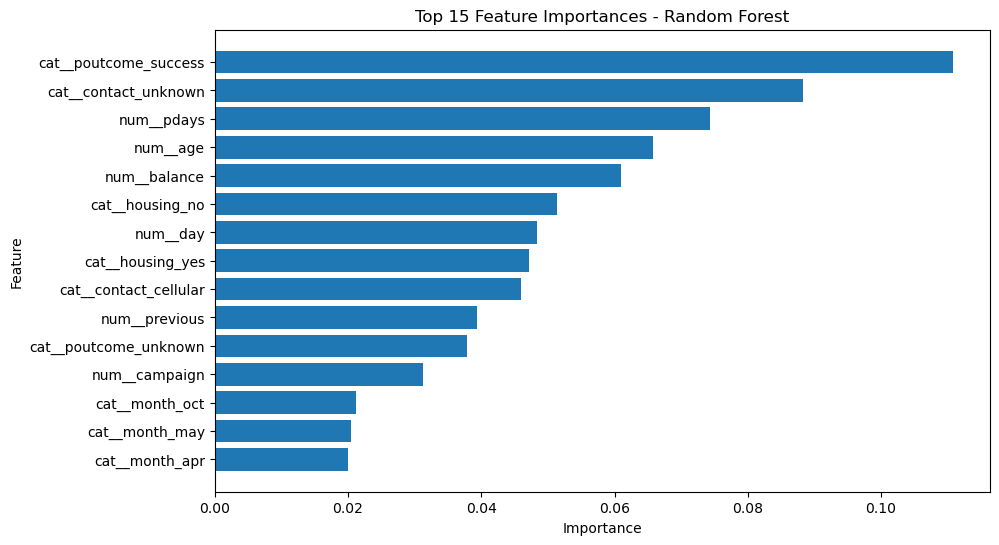

In [62]:
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

importances = random_forest_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

display(feature_importance_df.head(15))

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Iterative model development


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

param_distributions = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [8, 12, 16],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__max_features": ["sqrt", "log2", None]
}

random_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf_model = random_search.best_estimator_

y_pred_tuned_rf = best_rf_model.predict(X_test)

print("Best Parameters:")
print(random_search.best_params_)

print("\nTuned Random Forest Results using RandomizedSearchCV")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("Precision:", precision_score(y_test, y_pred_tuned_rf))
print("Recall:", recall_score(y_test, y_pred_tuned_rf))
print("F1 Score:", f1_score(y_test, y_pred_tuned_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_rf))

Best Parameters:
{'classifier__n_estimators': 150, 'classifier__min_samples_split': 10, 'classifier__max_features': 'log2', 'classifier__max_depth': 16}

Tuned Random Forest Results using RandomizedSearchCV
Accuracy: 0.8533672453831693
Precision: 0.4049645390070922
Recall: 0.5396975425330813
F1 Score: 0.4627228525121556

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      7985
           1       0.40      0.54      0.46      1058

    accuracy                           0.85      9043
   macro avg       0.67      0.72      0.69      9043
weighted avg       0.87      0.85      0.86      9043



Hyperparameter tuning was carried out using GridSearchCV to improve the Random Forest model. The model tested different values for n_estimators, max_depth and min_samples_split. F1-score was used as the scoring metric because the dataset is imbalanced and the project needs to balance precision and recall. The best parameters found were max_depth = 12, min_samples_split = 5 and n_estimators = 100. The tuned Random Forest model achieved an F1-score of 0.4475, which is slightly higher than the original Random Forest F1-score of 0.4366. This shows that iterative model development helped improve the model’s overall performance.

In [64]:
import joblib

joblib.dump(best_rf_model, "bank_marketing_model.pkl")

print("Final model saved successfully as bank_marketing_model.pkl")

Final model saved successfully as bank_marketing_model.pkl
